# GSK_HepG2 ablation: metric vs training-data fraction

Pulls the latest `gsk_hepg2_data_fraction` run from the `ablation` wandb project, recovers the per-`(fraction, model, seed)` rows from its history, and plots both models (chemprop vs deltaprop) on a single axis.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()`. A light line per seed connects that seed's points across the sweep, with the across-seed mean as a bold line and a matching-color +/- std band. **Each model has a single color** (chemprop = blue + dashed + square, deltaprop = orange + solid + circle); seeds are not color-coded.

GSK_HEPG2 is reported with `test_average_precision` (it is not `PK` / `SINGLE_TARGET_TBA`).

In [2]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_PREFIX = "gsk_hepg2_data_fraction"
RUN_NAME = None  # set to an exact run name to pin a specific run; otherwise use the latest
METRIC = "test_average_precision"  # GSK_HEPG2 metric; swap for test_roc_auc, test_mcc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
if RUN_NAME is not None:
    run = next(r for r in runs if r.name == RUN_NAME)
else:
    # Runs are named '<prefix>_<timestamp>'; pick the most recent matching run.
    matches = [r for r in runs if r.name.startswith(RUN_PREFIX)]
    run = max(matches, key=lambda r: r.created_at)
run.name, run.id

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/rahul/.netrc.


('gsk_hepg2_data_fraction_20260622_002225', '79yc4laa')

In [3]:
# Full, unsampled history -> one row per (fraction, model, seed).
df = pd.DataFrame(run.scan_history())
df = df[["fraction", "seed", "model", "n_train", METRIC]].sort_values(
    ["model", "fraction", "seed"]
)
df

,fraction,seed,model,n_train,test_average_precision
0,0.2,42,chemprop,2109,0.366372
10,0.2,53,chemprop,2109,0.401127
20,0.2,64,chemprop,2109,0.393843
30,0.2,75,chemprop,2109,0.422799
40,0.2,86,chemprop,2109,0.478212
2,0.4,42,chemprop,4212,0.391001
12,0.4,53,chemprop,4220,0.505898
22,0.4,64,chemprop,4218,0.502777
32,0.4,75,chemprop,4219,0.585545
42,0.4,86,chemprop,4217,0.477845


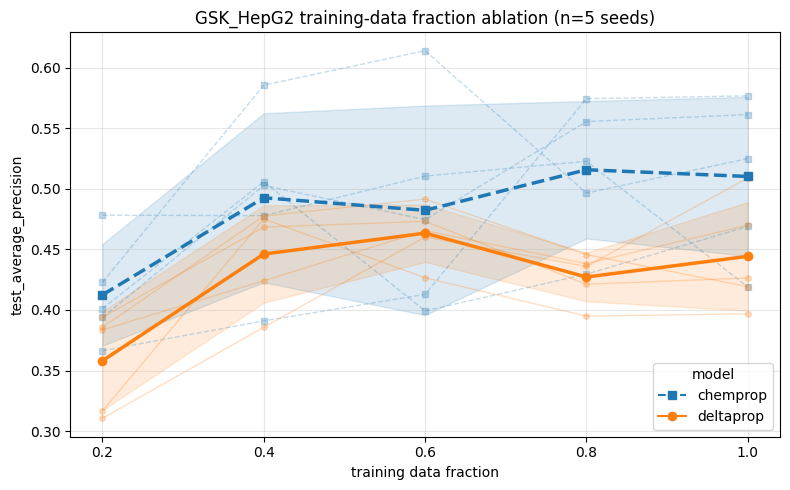

In [6]:
from matplotlib.lines import Line2D

# Both models on one axis, each with a single color + glyph + line dash (chemprop = blue,
# dashed, square; deltaprop = orange, solid, circle). Seeds are not color-coded: a light
# line per (model, seed) in the model's color connects that seed's points, and the
# across-seed mean is a bold line with a matching-color +/- std band.
models = sorted(df["model"].unique())
xticks = sorted(df["fraction"].dropna().unique())
n_seeds = df["seed"].nunique()

# Color + glyph + dash per model; fall back to a cycle for any unexpected model name.
preferred = {
    "chemprop": dict(color="tab:blue", marker="s", linestyle="--"),
    "deltaprop": dict(color="tab:orange", marker="o", linestyle="-"),
}
fallback = [
    dict(color="tab:green", marker="^", linestyle=":"),
    dict(color="tab:red", marker="D", linestyle="-."),
]
model_style = {}
for i, m in enumerate(models):
    model_style[m] = preferred.get(m, fallback[i % len(fallback)])

fig, ax = plt.subplots(figsize=(8, 5))

for model in models:
    style = model_style[model]
    g = df[df["model"] == model]

    # Per-seed traces: connect each seed's points across the sweep, light alpha.
    for seed, sg in g.groupby("seed"):
        sg = sg.sort_values("fraction")
        ax.plot(
            sg["fraction"],
            sg[METRIC],
            markersize=4,
            linewidth=1,
            alpha=0.25,
            zorder=2,
            **style,
        )

    # Across-seed mean + std band on top, same color as the model.
    agg = (
        g.groupby("fraction")[METRIC]
        .agg(mean="mean", std="std")
        .reset_index()
        .sort_values("fraction")
    )
    ax.plot(
        agg["fraction"],
        agg["mean"],
        linewidth=2.5,
        markersize=6,
        zorder=5,
        **style,
    )
    ax.fill_between(
        agg["fraction"],
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        color=style["color"],
        alpha=0.15,
        zorder=1,
    )

ax.set_xticks(xticks)
ax.set_xlabel("training data fraction")
ax.set_ylabel(METRIC)
ax.set_title(
    f"GSK_HepG2 training-data fraction ablation (n={n_seeds} seeds)"
)
ax.grid(True, alpha=0.3)

# Single legend keyed on the model (color + glyph + dash).
model_handles = [Line2D([0], [0], label=m, **model_style[m]) for m in models]
ax.legend(handles=model_handles, title="model", loc="lower right")

fig.tight_layout()
# fig.savefig("gsk_hepg2_ablation.png", dpi=150, bbox_inches="tight")
plt.show()